# 06 - Final Benchmark

Aggregates the artifacts from notebooks 01-05 into one leaderboard on the shared hold-out: point estimates, bootstrap CIs, Qini curves, decile charts, ERUPT policy values, and top-K capture shares. No models are trained or tuned here.

All notebooks used `SEED = 42`, `SAMPLE_SIZE = 500_000`, and the same stratified split on `(treatment × conversion)` with an untouched 20% hold-out, so the saved `qini_curves` are directly comparable; regenerating any notebook with a different seed breaks this. The DMLIV LATE from notebook 04 is a different estimand (compliers) and is excluded. Primary metric: Qini coefficient ([METRICS.md §1.2](METRICS.md)); the point-estimate table is a first look, the bootstrap tiers are the authority.

## Setup

In [1]:
import pickle, os, glob, warnings, time
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklift.metrics import uplift_auc_score, qini_auc_score, uplift_at_k
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
SEED = 42

## Load artifacts

One pickle per notebook (01-05); missing artifacts simply do not appear in the leaderboard.

In [2]:
ART = 'artifacts'
os.makedirs(ART, exist_ok=True)
files = sorted(glob.glob(f'{ART}/*.pkl'))
print('Found artifacts:')
for f in files: print(' ', f)

Found artifacts:
  artifacts/01_meta_learners.pkl
  artifacts/02_tree_methods.pkl
  artifacts/03_dml.pkl
  artifacts/04_advanced.pkl
  artifacts/05_hpo.pkl
  artifacts/05_hpo_best_params.pkl


In [3]:
all_results = {}
all_curves = {}
y_test = t_test = None

for f in files:
    if 'best_params' in f:
        continue
    with open(f, 'rb') as fh:
        blob = pickle.load(fh)
    all_results.update(blob['results'])
    all_curves.update(blob['qini_curves'])
    y_test = blob['y_test'] if y_test is None else y_test
    t_test = blob['t_test'] if t_test is None else t_test

print(f'Loaded {len(all_results)} models from artifacts.')
print('Models:', list(all_results.keys()))

Loaded 22 models from artifacts.
Models: ['Outcome-rank baseline', 'S-Learner (LGBM)', 'T-Learner (LGBM)', 'X-Learner (LGBM)', 'R-Learner (LGBM)', 'DR-Learner (LGBM)', 'DA-Learner (LGBM)', 'S-Learner (CB)', 'T-Learner (CB)', 'X-Learner (CB)', 'R-Learner (CB)', 'DR-Learner (CB)', 'DA-Learner (CB)', 'UpliftRF (KL)', 'CausalForest (GRF)', 'HonestCausalTree (depth=5)', 'LinearDML', 'SparseLinearDML', 'CausalForestDML', 'DR-Learner (AIPW)', 'DR-LGBM baseline', 'DR-LGBM tuned']


## Baseline: random ranking

Random ranking sets the noise floor. Its Qini is 0 in expectation, but on this hold-out the executed value is about $-0.05$, and the bootstrap puts the standard deviation of a random ranking's Qini around $0.03$-$0.05$. Small non-zero Qini values are within baseline noise.

In [4]:
if y_test is not None:
    rng = np.random.RandomState(SEED)
    rnd_scores = rng.uniform(size=len(y_test))
    all_results['Random baseline'] = {
        'AUUC': round(uplift_auc_score(y_test, rnd_scores, t_test), 6),
        'Qini': round(qini_auc_score(y_test, rnd_scores, t_test), 6),
        'Uplift@10%': round(uplift_at_k(y_test, rnd_scores, t_test, strategy='by_group', k=0.1), 4),
        'Uplift@20%': round(uplift_at_k(y_test, rnd_scores, t_test, strategy='by_group', k=0.2), 4),
        'Time(s)': 0.0,
    }
    all_curves['Random baseline'] = rnd_scores
    print('Added Random baseline.')
else:
    print('No y_test loaded; skip baselines.')

Added Random baseline.


## Leaderboard

Sorted by Qini, descending; also written to CSV.

In [5]:
df = pd.DataFrame(all_results).T.astype(float).sort_values('Qini', ascending=False)
print('\n=== Final Leaderboard (sorted by Qini) ===')
print(df.to_string(float_format=lambda x: f'{x:.6f}' if abs(x) < 10 else f'{x:.1f}'))
df.to_csv('leaderboard.csv')
print('\nSaved leaderboard.csv')

df.style.background_gradient(subset=['AUUC','Qini','Uplift@10%','Uplift@20%'], cmap='Greens') \
        .background_gradient(subset=['Time(s)'], cmap='Reds_r') \
        .format({'AUUC':'{:.6f}','Qini':'{:.6f}','Uplift@10%':'{:.4f}','Uplift@20%':'{:.4f}','Time(s)':'{:.1f}'})


=== Final Leaderboard (sorted by Qini) ===
                                AUUC      Qini  Uplift@10%  Uplift@20%  Time(s)
DR-Learner (LGBM)           0.008547  0.253319    0.013200    0.006700    208.6
R-Learner (CB)              0.008119  0.240742    0.013300    0.006500     16.6
Outcome-rank baseline       0.007051  0.208940    0.012400    0.006100 2.700000
HonestCausalTree (depth=5)  0.006691  0.198077    0.010800    0.006200 0.300000
T-Learner (LGBM)            0.006416  0.190324    0.013100    0.006000 4.400000
DR-Learner (CB)             0.006293  0.186780    0.011500    0.005400    302.7
SparseLinearDML             0.006249  0.185848    0.012500    0.005300    215.0
CausalForest (GRF)          0.006235  0.185171    0.012700    0.006700     22.8
CausalForestDML             0.006150  0.182506    0.012000    0.006600     76.9
LinearDML                   0.005682  0.169127    0.011300    0.005300     35.1
S-Learner (CB)              0.005437  0.161378    0.009800    0.005800 4.500

,AUUC,Qini,Uplift@10%,Uplift@20%,Time(s)
DR-Learner (LGBM),0.008547,0.253319,0.0132,0.0067,208.6
R-Learner (CB),0.008119,0.240742,0.0133,0.0065,16.6
Outcome-rank baseline,0.007051,0.208940,0.0124,0.0061,2.7
HonestCausalTree (depth=5),0.006691,0.198077,0.0108,0.0062,0.3
T-Learner (LGBM),0.006416,0.190324,0.0131,0.0060,4.4
DR-Learner (CB),0.006293,0.186780,0.0115,0.0054,302.7
SparseLinearDML,0.006249,0.185848,0.0125,0.0053,215.0
CausalForest (GRF),0.006235,0.185171,0.0127,0.0067,22.8
CausalForestDML,0.006150,0.182506,0.0120,0.0066,76.9
LinearDML,0.005682,0.169127,0.0113,0.0053,35.1


## Bootstrap Qini CIs and tiers

Stratified paired bootstrap of the hold-out: resample with replacement within the four (treatment × outcome) cells (preserving arm sizes and positive counts) and recompute every model's Qini on the same resample. Reports per-model 95% CIs and, against the current leader, the fraction of resamples the leader wins; models the leader does not beat in ≥97.5% of resamples form the top tier - statistically indistinguishable from it.

In [6]:
# Stratified paired bootstrap of the hold-out (see the note above).
# Resample with replacement *within* each (treatment x outcome) cell so every
# resample keeps the same arm sizes and positive counts, then recompute every
# model's Qini on that same resample. Sharing rows across models (paired) makes
# their differences far less noisy than their individual CIs suggest.
from sklift.metrics import qini_auc_score

B = 300
rng = np.random.RandomState(SEED)
names = [n for n in df.index.tolist() if n in all_curves]
yv, tv = np.asarray(y_test), np.asarray(t_test)
score_vecs = {n: np.asarray(all_curves[n]).flatten() for n in names}

cells = [np.where((tv == ti) & (yv == yi))[0] for ti in (0, 1) for yi in (0, 1)]
cells = [c for c in cells if len(c) > 0]

boot = {n: np.empty(B) for n in names}
for b in range(B):
    idx = np.concatenate([c[rng.randint(0, len(c), len(c))] for c in cells])
    yb, tb = yv[idx], tv[idx]
    for n in names:
        boot[n][b] = qini_auc_score(yb, score_vecs[n][idx], tb)

leader = names[0]  # df is sorted by Qini, so this is the point-estimate winner
rows = []
for n in names:
    lo, hi = np.percentile(boot[n], [2.5, 97.5])
    p_beat = np.nan if n == leader else round(float(np.mean(boot[leader] > boot[n])), 3)
    rows.append({'Qini': round(df.loc[n, 'Qini'], 4),
                 'CI_lo': round(float(lo), 4), 'CI_hi': round(float(hi), 4),
                 'P(leader>this)': p_beat})
ci_df = pd.DataFrame(rows, index=names)

# Top tier: the leader plus every model it fails to beat in >=97.5% of resamples.
top_tier = [n for n in names
            if n == leader or float(np.mean(boot[leader] > boot[n])) < 0.975]

print(f'Bootstrap: B={B} stratified paired resamples. Leader = {leader}\n')
print(ci_df.to_string(float_format=lambda x: f'{x:.4f}'))
print(f'\nTop tier (indistinguishable from leader at 97.5%): {top_tier}')

Bootstrap: B=300 stratified paired resamples. Leader = DR-Learner (LGBM)

                              Qini   CI_lo  CI_hi  P(leader>this)
DR-Learner (LGBM)           0.2533  0.1082 0.3945             NaN
R-Learner (CB)              0.2407  0.1248 0.3787          0.5870
Outcome-rank baseline       0.2089  0.1732 0.2424          0.6900
HonestCausalTree (depth=5)  0.1981  0.1046 0.2881          0.6870
T-Learner (LGBM)            0.1903  0.0801 0.3143          0.8170
DR-Learner (CB)             0.1868  0.0792 0.3209          0.7400
SparseLinearDML             0.1858  0.1515 0.2158          0.7730
CausalForest (GRF)          0.1852  0.1465 0.2196          0.7830
CausalForestDML             0.1825  0.1434 0.2164          0.7870
LinearDML                   0.1691  0.1380 0.1948          0.8330
S-Learner (CB)              0.1614  0.0987 0.2320          0.8770
DR-LGBM baseline            0.1586  0.0231 0.2935          0.9400
S-Learner (LGBM)            0.1434  0.0342 0.2588          0.9430
R-

## Qini curves

All models on one axis. Curves with similar area can differ in shape; at a fixed top-K% budget, read Qini@K rather than the overall area.

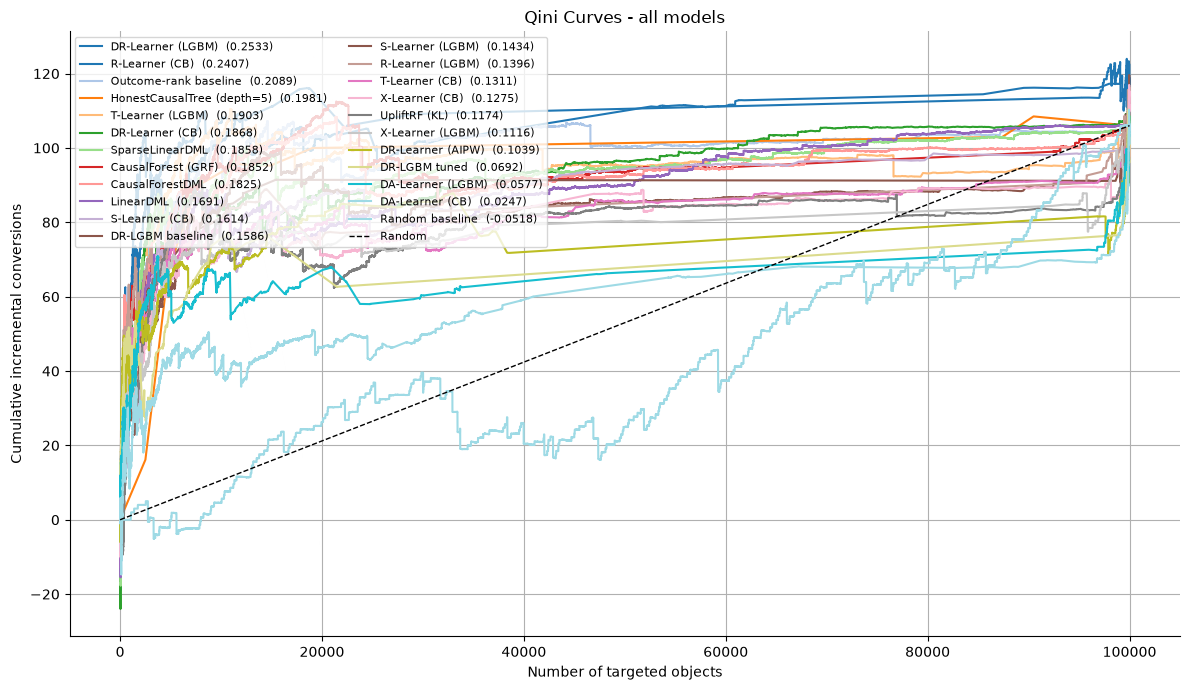

In [7]:
# Draw the Qini curves by hand (see notebook 02): calling plot_qini_curve
# several times on one axis breaks on matplotlib >= 3.7, so we plot each directly.
from sklift.metrics import qini_curve
fig, ax = plt.subplots(figsize=(12, 7))
order = [n for n in df.index.tolist() if n in all_curves]
colors = plt.cm.tab20(np.linspace(0, 1, len(order)))
end = None
for name, c in zip(order, colors):
    x, y = qini_curve(y_test, np.asarray(all_curves[name]).flatten(), t_test)
    ax.plot(x, y, label=f'{name}  ({df.loc[name,"Qini"]:.4f})', color=c)
    end = (x[-1], y[-1])
if end is not None:
    ax.plot([0, end[0]], [0, end[1]], 'k--', lw=1, label='Random')
ax.set_title('Qini Curves - all models')
ax.set_xlabel('Number of targeted objects')
ax.set_ylabel('Cumulative incremental conversions')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout(); plt.savefig('benchmark_qini_all.png', dpi=140, bbox_inches='tight'); plt.show()

## Qini bar chart

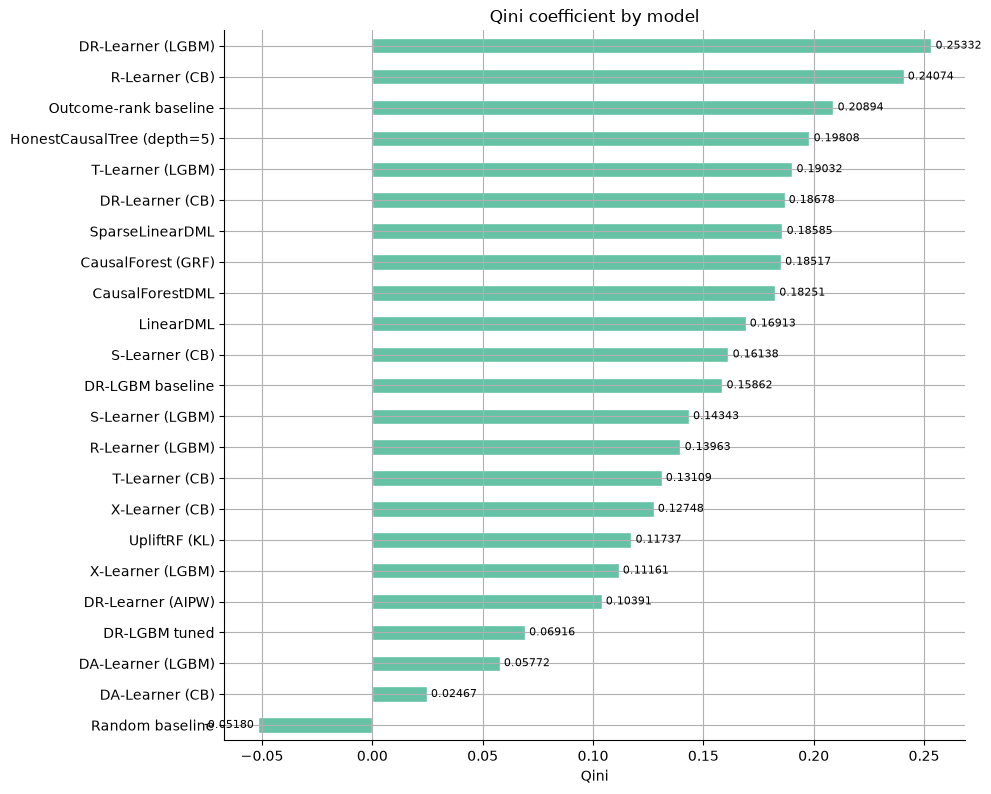

In [8]:
fig, ax = plt.subplots(figsize=(10, max(4, 0.35*len(df))))
df['Qini'].sort_values().plot.barh(ax=ax, color='#66c2a5', edgecolor='white')
ax.bar_label(ax.containers[0], fmt='%.5f', padding=3, fontsize=8)
ax.set_title('Qini coefficient by model')
ax.set_xlabel('Qini')
plt.tight_layout(); plt.savefig('benchmark_qini_bar.png', dpi=140, bbox_inches='tight'); plt.show()

## Decile chart, top-3 models

Hold-out sorted by predicted $\hat\tau$, binned into 10 deciles; each bar is the within-decile $\bar Y_{T=1} - \bar Y_{T=0}$. A monotonic decrease indicates a usable ranking. Per-decile differences are noisy at this scale; read shapes, not exact bar heights.

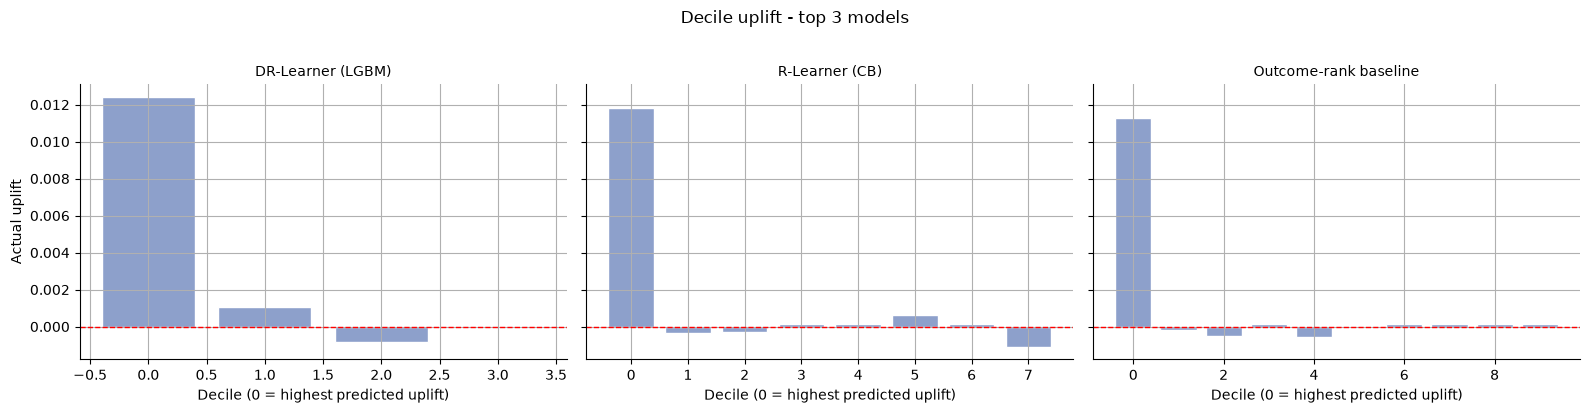

In [9]:
def uplift_by_decile(y, scores, treatment, n=10):
    d = pd.DataFrame({'y': y, 't': treatment, 's': scores})
    d['decile'] = pd.qcut(d['s'], q=n, labels=False, duplicates='drop')
    d['decile'] = d['decile'].max() - d['decile']
    return d.groupby('decile').apply(
        lambda g: g.loc[g.t==1,'y'].mean() - g.loc[g.t==0,'y'].mean()
        if (g.t==1).sum()>0 and (g.t==0).sum()>0 else np.nan
    )

top3 = df.head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, name in zip(axes, top3):
    vals = uplift_by_decile(y_test, all_curves[name], t_test)
    ax.bar(vals.index, vals.values, color='#8da0cb', edgecolor='white')
    ax.axhline(0, color='red', lw=1, linestyle='--')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Decile (0 = highest predicted uplift)')
axes[0].set_ylabel('Actual uplift')
plt.suptitle('Decile uplift - top 3 models', y=1.02)
plt.tight_layout(); plt.savefig('benchmark_top3_deciles.png', dpi=140, bbox_inches='tight'); plt.show()

## Policy value (ERUPT)

Horvitz-Thompson IPS estimate of the value of "treat the exact top-K% by rank" (using the known RCT assignment probability), compared against treat-everyone and treat-no-one. The hold-out has ~300 conversions, so policy-value gaps between models are within noise; treat rank differences as suggestive, not decisive.

In [10]:
e = t_test.mean()   # known RCT assignment probability P(T=1), ~0.85 on Criteo

def policy_value(scores, k):
    s = np.asarray(scores).flatten()
    # Exact top-k% by rank. `s >= quantile` over-selects when scores tie, which
    # would silently turn some rows into near-treat-all policies.
    pi = np.zeros(len(s), dtype=int)
    pi[np.argsort(-s, kind='stable')[:int(len(s) * k)]] = 1  # 1 = treat top-k%
    p_assign = np.where(pi == 1, e, 1 - e)
    return np.mean(y_test * (pi == t_test) / p_assign)      # IPS estimate of E[Y(pi)]

v_all  = np.mean(y_test * t_test / e)                        # treat everyone  -> E[Y(1)]
v_none = np.mean(y_test * (1 - t_test) / (1 - e))            # treat no one    -> E[Y(0)]

# All scored models except the random baseline (not a targeting policy).
model_names = [m for m in all_curves if m != 'Random baseline']

erupt = pd.DataFrame(
    [{'V@10%': policy_value(all_curves[m], 0.1),
      'V@20%': policy_value(all_curves[m], 0.2),
      'V@30%': policy_value(all_curves[m], 0.3)}
     for m in model_names],
    index=model_names,
).sort_values('V@20%', ascending=False)

print(f'Reference policies:  treat-all V={v_all:.6f}   treat-none V={v_none:.6f}')
print('(a targeting policy is only worth it if V > both references)\n')
print(erupt.to_string(float_format=lambda x: f'{x:.6f}'))

Reference policies:  treat-all V=0.003247   treat-none V=0.002000
(a targeting policy is only worth it if V > both references)

                              V@10%    V@20%    V@30%
DR-Learner (LGBM)          0.003318 0.003345 0.003318
CausalForest (GRF)         0.003282 0.003345 0.003161
CausalForestDML            0.003204 0.003322 0.003137
R-Learner (CB)             0.003325 0.003302 0.003275
Outcome-rank baseline      0.003314 0.003294 0.003243
HonestCausalTree (depth=5) 0.003325 0.003247 0.003271
T-Learner (LGBM)           0.003314 0.003200 0.003204
S-Learner (LGBM)           0.003145 0.003188 0.003059
S-Learner (CB)             0.003129 0.003153 0.003031
DR-Learner (CB)            0.003145 0.003145 0.003071
DR-LGBM baseline           0.003016 0.003133 0.003180
LinearDML                  0.003200 0.003067 0.003035
SparseLinearDML            0.003247 0.003055 0.003184
T-Learner (CB)             0.003098 0.003035 0.002984
DR-Learner (AIPW)          0.002925 0.003024 0.003051
X-Learne

## Top-K capture share

For $K \in \{5\%, 10\%, 20\%, 30\%, 50\%\}$:

$$
\mathrm{Incremental}_K \;=\; \Big(\bar Y_{T=1}^{\text{top-K\%}} - \bar Y_{T=0}^{\text{top-K\%}}\Big) \cdot N_K
$$

where $N_K = K \cdot N_{\text{test}}$. Dividing by the same quantity on the entire hold-out gives the share of incremental conversions captured by targeting the top-K%. Unbiased without reweighting only because Criteo is an RCT. The top-K control slices hold only a handful of conversions, so the shares are very noisy and can exceed 100%; read them qualitatively.

In [11]:
best = df.index[0]
scores = all_curves[best]
order = np.argsort(-scores)
y_sorted = y_test[order]; t_sorted = t_test[order]

# Total incremental conversions in the test set
total_inc = (y_test[t_test==1].sum() / t_test.sum()
             - y_test[t_test==0].sum() / (1 - t_test).sum()) * len(y_test)

def cum_incr(k):
    n = int(len(y_sorted) * k)
    sl_y = y_sorted[:n]; sl_t = t_sorted[:n]
    if sl_t.sum()==0 or (1-sl_t).sum()==0: return np.nan
    return (sl_y[sl_t==1].sum()/sl_t.sum() - sl_y[sl_t==0].sum()/(1-sl_t).sum()) * n

for k in [0.05, 0.1, 0.2, 0.3, 0.5]:
    inc = cum_incr(k)
    print(f'Top {k*100:>4.0f}%  →  incremental ≈ {inc:.1f}  ({inc/total_inc:.1%} of total)')

Top    5%  →  incremental ≈ 115.1  (92.3% of total)
Top   10%  →  incremental ≈ 124.2  (99.6% of total)
Top   20%  →  incremental ≈ 128.7  (103.2% of total)
Top   30%  →  incremental ≈ 127.6  (102.4% of total)
Top   50%  →  incremental ≈ 126.4  (101.4% of total)


## Conclusions

- The point-estimate leaderboard ranks ~22 models on a hold-out whose control arm holds only ~30 conversions (about 300 in total); the exact ordering is mostly noise. Read the bootstrap top tier (models statistically indistinguishable from the leader), not row order.
- The textbook ranking DR > R > X > T > S is a hypothesis the tiers answer, not a result to assert.
- Two floors: random ranking (Qini ≈ 0) and the outcome-rank baseline from notebook 01. A CATE model that does not clear outcome-rank is not a deployment candidate.
- Qini ranks users; ERUPT evaluates the induced treat/don't-treat rule. Pick on ERUPT when the goal is a policy at a fixed budget.
- `DR-Learner (LGBM)` (01), `DR-Learner (AIPW)` (04), and `DR-LGBM baseline/tuned` (05) are one model family, not independent entries.

Reproducibility: all notebooks share `SEED = 42`, `SAMPLE_SIZE = 500_000`, and the same stratified split on `(treatment × conversion)`; the 20% hold-out is never seen during HPO. Re-running any notebook with a different seed breaks cross-notebook comparability.

Caveats: results come from one executed 500K run on a single split; the bootstrap quantifies test-side noise only, not train-side variance. For a publishable ranking, rerun the top models across split seeds and on the full ~14M-row dataset (≥1M-row hold-out). Criteo is a clean RCT with perfect overlap and low dimensionality; numbers do not transfer to confounded observational settings.

See [METRICS.md](METRICS.md) and [RESEARCH.md](RESEARCH.md) for metrics and background.